In [10]:
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

# 1. Set up and verify paths
project_root = r"c:\Users\ngait\FairwayIQ\FairwayIQ"
data_dir = os.path.join(project_root, "data")
os.makedirs(data_dir, exist_ok=True)

print("⏳ Generating synthetic club datasets...")

# Set random seed for consistency
np.random.seed(42)
num_members = 200

# 2. Generate Members Master Data
member_ids = np.arange(1001, 1001 + num_members)
names = [f"Player {i}" for i in member_ids]
handicaps = np.random.randint(0, 28, size=num_members)
join_years = np.random.choice([2021, 2022, 2023, 2024, 2025], size=num_members)

df_members = pd.DataFrame({
    "MemberID": member_ids,
    "PlayerName": names,
    "Handicap": handicaps,
    "JoinYear": join_years
})
df_members.to_csv(os.path.join(data_dir, "members.csv"), index=False)

# 3. Generate Engagement Data (Rounds played per month over last 6 months)
engagement_records = []
for m_id in member_ids:
    # High engagement members vs at-risk members
    is_at_risk = np.random.choice([0, 1], p=[0.75, 0.25])
    for month in range(1, 7):
        if is_at_risk and month > 4:
            # Dropping engagement
            rounds = np.random.randint(0, 2)
        else:
            rounds = np.random.randint(2, 8)
        engagement_records.append({"MemberID": m_id, "Month": month, "RoundsPlayed": rounds})

df_engagement = pd.DataFrame(engagement_records)
df_engagement.to_csv(os.path.join(data_dir, "engagement.csv"), index=False)

# 4. Generate Revenue Data
revenue_records = []
for m_id in member_ids:
    base_fee = 15000  # Base club subscription dues
    spend = np.random.randint(1000, 12000)  # Pro-shop & Restaurant spend
    revenue_records.append({"MemberID": m_id, "SubscriptionFee": base_fee, "AncillarySpend": spend})

df_revenue = pd.DataFrame(revenue_records)
df_revenue.to_csv(os.path.join(data_dir, "revenue.csv"), index=False)

# 5. Generate Target Variable (Member Status: 0 = Active, 1 = Churned/Dropped out)
# If rounds played in month 6 is low, higher chance of churn status
status_records = []
for m_id in member_ids:
    m_rounds = df_engagement[(df_engagement["MemberID"] == m_id) & (df_engagement["Month"] == 6)]["RoundsPlayed"].values[0]
    churn_prob = 0.85 if m_rounds <= 1 else 0.05
    status = np.random.choice([0, 1], p=[1 - churn_prob, churn_prob])
    status_records.append({"MemberID": m_id, "ChurnStatus": status})

df_status = pd.DataFrame(status_records)
df_status.to_csv(os.path.join(data_dir, "member_status.csv"), index=False)

print("🎯 Success! Datasets created and saved cleanly inside your data folder.")
print(f"📊 Loaded {len(df_members)} member profiles ready for AI training.")

⏳ Generating synthetic club datasets...
🎯 Success! Datasets created and saved cleanly inside your data folder.
📊 Loaded 200 member profiles ready for AI training.


In [11]:
# --- STEP 2: AGGREGATE & COMBINE DATA FOR ML ---

# 1. Calculate historical playing activity metrics from engagement records
# Find total rounds played and average monthly rounds over the 6-month timeline
activity_summary = df_engagement.groupby('MemberID').agg(
    TotalRounds=('RoundsPlayed', 'sum'),
    AvgMonthlyRounds=('RoundsPlayed', 'mean')
).reset_index()

# 2. Extract recent momentum trends (how many rounds did they play in the absolute final month?)
recent_activity = df_engagement[df_engagement['Month'] == 6][['MemberID', 'RoundsPlayed']].rename(
    columns={'RoundsPlayed': 'RecentMonthRounds'}
)

# 3. Merge all operational silos together into one consolidated AI matrix
df_ml = pd.merge(df_members, activity_summary, on='MemberID', how='inner')
df_ml = pd.merge(df_ml, recent_activity, on='MemberID', how='inner')
df_ml = pd.merge(df_ml, df_revenue, on='MemberID', how='inner')
df_ml = pd.merge(df_ml, df_status, on='MemberID', how='inner')

# Calculate total wallet spend at the facility
df_ml['TotalSpend'] = df_ml['SubscriptionFee'] + df_ml['AncillarySpend']

print("🎯 AI Training Matrix Compiled Successfully!")
print(f"Spreadsheet Dimensions: {df_ml.shape[0]} members x {df_ml.shape[1]} structural variables.\n")

# Display a preview of the consolidated data structure
df_ml.head()

🎯 AI Training Matrix Compiled Successfully!
Spreadsheet Dimensions: 200 members x 11 structural variables.



,MemberID,PlayerName,Handicap,JoinYear,TotalRounds,AvgMonthlyRounds,RecentMonthRounds,SubscriptionFee,AncillarySpend,ChurnStatus,TotalSpend
0,1001,Player 1001,6,2024,18,3.000000,0,15000,2763,1,17763
1,1002,Player 1002,19,2024,33,5.500000,7,15000,9712,0,24712
2,1003,Player 1003,14,2024,32,5.333333,6,15000,6797,0,21797
3,1004,Player 1004,10,2024,32,5.333333,5,15000,10208,0,25208
4,1005,Player 1005,7,2024,22,3.666667,0,15000,8099,1,23099


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Separate features from target variable
X = df_ml.drop(columns=['MemberID', 'PlayerName', 'ChurnStatus'])
y = df_ml['ChurnStatus']

# 2. Split the data into a Training Set (80%) and a Testing Set (20%) using 'test_size'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and train the Random Forest AI Engine
ai_model = RandomForestClassifier(n_estimators=100, random_state=42)
ai_model.fit(X_train, y_train)

# 4. Run predictions on our test holding group
y_pred = ai_model.predict(X_test)

# 5. Output the performance metrics
print("🏆 FairwayIQ Predictive Engine Training Complete!")
print(f"🎯 Model Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("📋 Detailed Performance Classification Report:")
print(classification_report(y_test, y_pred))

🏆 FairwayIQ Predictive Engine Training Complete!
🎯 Model Accuracy Score: 95.00%

📋 Detailed Performance Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        31
           1       1.00      0.78      0.88         9

    accuracy                           0.95        40
   macro avg       0.97      0.89      0.92        40
weighted avg       0.95      0.95      0.95        40



C:\Users\ngait\AppData\Local\Temp\ipykernel_18064\550207251.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
C:\Users\ngait\AppData\Local\Temp\ipykernel_18064\550207251.py:19: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ngait\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


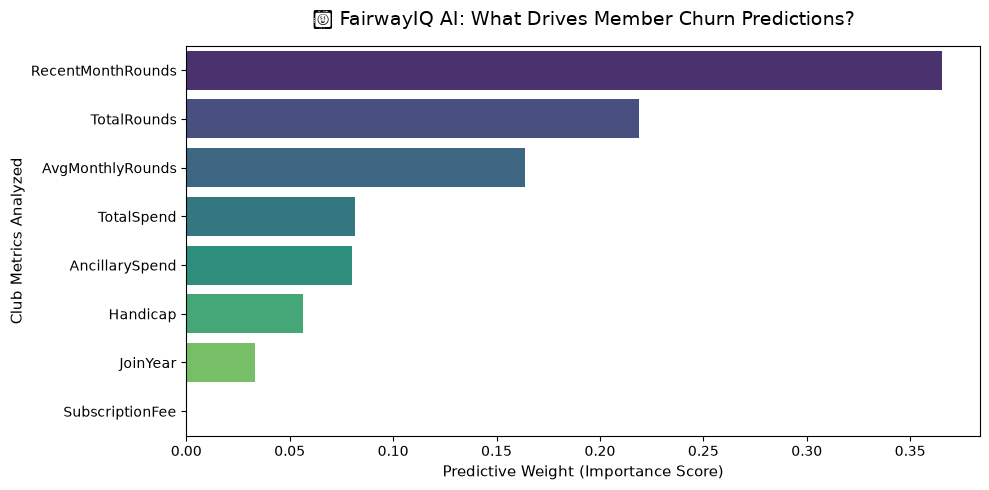

📋 Raw Feature Importance Rankings:
          Feature  Importance
RecentMonthRounds    0.365486
      TotalRounds    0.218903
 AvgMonthlyRounds    0.163868
       TotalSpend    0.081544
   AncillarySpend    0.080355
         Handicap    0.056439
         JoinYear    0.033404
  SubscriptionFee    0.000000


In [14]:
# --- STEP 4: VISUALIZE WHAT DRIVES MEMBER CHURN ---

# Extract importance scores from the trained model
importances = ai_model.feature_importances_
feature_names = X.columns

# Organize into a clean, sorted DataFrame
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Render a professional data science bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('🧠 FairwayIQ AI: What Drives Member Churn Predictions?', fontsize=14, pad=15)
plt.xlabel('Predictive Weight (Importance Score)', fontsize=11)
plt.ylabel('Club Metrics Analyzed', fontsize=11)
plt.tight_layout()
plt.show()

# Print the text breakdown
print("📋 Raw Feature Importance Rankings:")
print(df_importance.to_string(index=False))

In [9]:
import os

# Start from your user directory and look for the data files
search_root = r"c:\Users\ngait\FairwayIQ"
print(f"Searching for data files starting from: {search_root}\n")

found_any = False
for root, dirs, files in os.walk(search_root):
    for file in files:
        if file in ['members.csv', 'live_leaderboard.csv']:
            print(f"🎯 Found file: {file}")
            print(f"📍 Location: {os.path.join(root, file)}\n")
            found_any = True

if not found_any:
    print("❌ Could not find any target CSV files in the directory tree.")

Searching for data files starting from: c:\Users\ngait\FairwayIQ

🎯 Found file: live_leaderboard.csv
📍 Location: c:\Users\ngait\FairwayIQ\FairwayIQ\live_leaderboard.csv

🎯 Found file: live_leaderboard.csv
📍 Location: c:\Users\ngait\FairwayIQ\FairwayIQ\data\live_leaderboard.csv



In [7]:
import os
print("1. Current folder Python is in:", os.getcwd())
print("2. Files available in this folder:", os.listdir('.'))

# Let's see if jumping up one more level fixes the double nesting
test_path = os.path.abspath(os.path.join(os.getcwd(), "../..", "data"))
if os.path.exists(test_path):
    print("🎯 Found it! The true data folder is two levels up:", test_path)
else:
    print("❌ Data folder not found at two levels up either.")
    

1. Current folder Python is in: c:\Users\ngait\FairwayIQ\FairwayIQ\notebooks
2. Files available in this folder: ['02_Churn_Prediction.ipynb']
❌ Data folder not found at two levels up either.


!pip install matplotlib seaborn


In [3]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 2.8 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.3 MB 1.7 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.3 MB 1.7 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.3 MB 1.3 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.3 MB 1.5 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.3 MB 1.5 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.3 MB 1.6 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.3 MB 1.6 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.3 MB 1.7 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.3 MB 1.7 MB/s eta 0:00:04
   ----------------- ---